In [ ]:
# ノートブック上で
!pip install -r requirements.txt

In [5]:
import json
import os
import time

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm

from pointnet2 import PointNet2
from wads_dataset import WADSDataset
from inference_wads import load_pointcloud, sample_points, evaluate_test_set, print_evaluation_results

In [7]:
root = "./WADS/wads"  # WADSデータセットのルートディレクトリ
splits_file = "splits.json"  # データ分割定義ファイル
num_points = 16384  # サンプリング点数
batch_size = 2
epochs = 50
lr = 1e-3
weight_decay = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# CUDAメモリの最適化設定
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(
        f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
    )
    print(f"Initial Allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
    print(f"Initial Reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")

# ───────────────────────────────
# Dataset / DataLoader
# ───────────────────────────────
print("\n" + "=" * 60)
print("Loading WADS Dataset...")
print("=" * 60)

train_dataset = WADSDataset(
    root, split="train", num_points=num_points, splits_file=splits_file
)
val_dataset = WADSDataset(
    root, split="val", num_points=num_points, splits_file=splits_file
)

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=4
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False, num_workers=4
)

print(f"\nTrain samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

# ───────────────────────────────
# Model
# ───────────────────────────────
print("\n" + "=" * 60)
print("Initializing Model...")
print("=" * 60)
model = PointNet2(in_dim=5, num_classes=2, num_points=num_points).to(device)

# クラス不均衡対策：ノイズ点（クラス1）に重みを付ける
class_weights = torch.tensor([1.0, 10.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

Using: cuda
GPU Memory: 6.00 GB
Initial Allocated: 0.00 GB
Initial Reserved: 0.00 GB

Loading WADS Dataset...
Loading train split with sequences: [11, 12, 13, 14, 15, 16, 17, 18, 20, 22, 23, 24, 26]
  Sequence 11: 102 files
  Sequence 12: 101 files
  Sequence 13: 101 files
  Sequence 14: 101 files
  Sequence 15: 102 files
  Sequence 16: 102 files
  Sequence 17: 101 files
  Sequence 18: 101 files
  Sequence 20: 101 files
  Sequence 22: 101 files
  Sequence 23: 101 files
  Sequence 24: 101 files
  Sequence 26: 101 files
Total train samples: 1316
Loading val split with sequences: [28, 30]
  Sequence 28: 102 files
  Sequence 30: 101 files
Total val samples: 203

Train samples: 1316
Val samples: 203

Initializing Model...


In [8]:
# ───────────────────────────────
# 学習開始時刻を記録
# ───────────────────────────────
# start_time = time.time()
# print("\n" + "=" * 60)
# print("Starting Training...")
# print("=" * 60 + "\n")

# ───────────────────────────────
# Training Loop
# ───────────────────────────────
best_val_loss = float("inf")

# 学習曲線用のリスト
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    total_correct = 0
    total_points = 0

    # tqdmで進捗バーを表示
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", ncols=100)

    for i, (points, labels) in enumerate(pbar):
        points = points.to(device)  # (B, N, 5)
        labels = labels.to(device)  # (B, N)

        optimizer.zero_grad()

        # Forward
        logits = model(points)  # (B, N, 2)
        logits = logits.permute(0, 2, 1)  # (B, 2, N)

        # Loss
        loss = criterion(logits, labels)

        # Backprop
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Accuracy
        preds = logits.argmax(dim=1)  # (B, N)
        total_correct += (preds == labels).sum().item()
        total_points += labels.numel()

        # 進捗バーに現在の統計を表示
        current_loss = total_loss / (i + 1)
        current_acc = total_correct / total_points
        pbar.set_postfix(
            {"loss": f"{current_loss:.4f}", "acc": f"{current_acc:.4f}"}
        )

        # メモリ解放
        del points, labels, logits, preds, loss
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    avg_train_loss = total_loss / len(train_loader)
    train_acc = total_correct / total_points
    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)
    print(
        f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}"
    )

    # ───────────────────────────────
    # Validation
    # ───────────────────────────────
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    # クラスごとの精度を追跡
    class_correct = [0, 0]
    class_total = [0, 0]

    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]  ", ncols=100)

    with torch.no_grad():
        for points, labels in val_pbar:
            points = points.to(device)
            labels = labels.to(device)

            logits = model(points)
            logits = logits.permute(0, 2, 1)

            loss = criterion(logits, labels)
            val_loss += loss.item()

            # accuracy
            preds = logits.argmax(dim=1)  # (B, N)
            correct += (preds == labels).sum().item()
            total += labels.numel()

            # クラスごとの精度
            for c in range(2):
                class_mask = labels == c
                class_correct[c] += ((preds == labels) & class_mask).sum().item()
                class_total[c] += class_mask.sum().item()

            # メモリ解放
            del points, labels, logits, preds, loss
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / total
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    # クラスごとの精度を表示
    class0_acc = class_correct[0] / class_total[0] if class_total[0] > 0 else 0
    class1_acc = class_correct[1] / class_total[1] if class_total[1] > 0 else 0

    print(f"  Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print(
        f"  Class 0 (Normal) Acc: {class0_acc:.4f} | Class 1 (Noise) Acc: {class1_acc:.4f}"
    )

    # Learning rate scheduler step
    scheduler.step()

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        os.makedirs("checkpoints", exist_ok=True)
        save_path = "checkpoints/pointnet2_best.pth"
        torch.save(model.state_dict(), save_path)
        print(f"  ★ Best model saved: {save_path}")

Epoch 1/50 [Train]: 100%|████████████████| 658/658 [28:21<00:00,  2.59s/it, loss=0.2828, acc=0.9179]


Epoch 1 | Train Loss: 0.2828 | Train Acc: 0.9179


Epoch 1/50 [Val]  : 100%|█████████████████████████████████████████| 102/102 [04:42<00:00,  2.77s/it]


  Val Loss: 0.2272 | Val Acc: 0.9360
  Class 0 (Normal) Acc: 0.9378 | Class 1 (Noise) Acc: 0.9178
  ★ Best model saved: checkpoints/pointnet2_best.pth


Epoch 2/50 [Train]: 100%|████████████████| 658/658 [30:38<00:00,  2.79s/it, loss=0.2456, acc=0.9414]


...

Epoch 12 | Train Loss: 0.1999 | Train Acc: 0.9455


Epoch 12/50 [Val]  : 100%|████████████████████████████████████████| 102/102 [04:57<00:00,  2.92s/it]


  Val Loss: 0.2104 | Val Acc: 0.8965
  Class 0 (Normal) Acc: 0.8921 | Class 1 (Noise) Acc: 0.9395


Epoch 13/50 [Train]:  36%|█████▎         | 234/658 [11:50<21:27,  3.04s/it, loss=0.1893, acc=0.9493]


KeyboardInterrupt: 

In [9]:
# ───────────────────────────────
# Save final model
# ───────────────────────────────
os.makedirs("checkpoints", exist_ok=True)
save_path = "checkpoints/pointnet2_final.pth"
torch.save(model.state_dict(), save_path)
print(f"\nFinal model saved to {save_path}")


Final model saved to checkpoints/pointnet2_final.pth


Learning curve saved to results/learning_curve.png


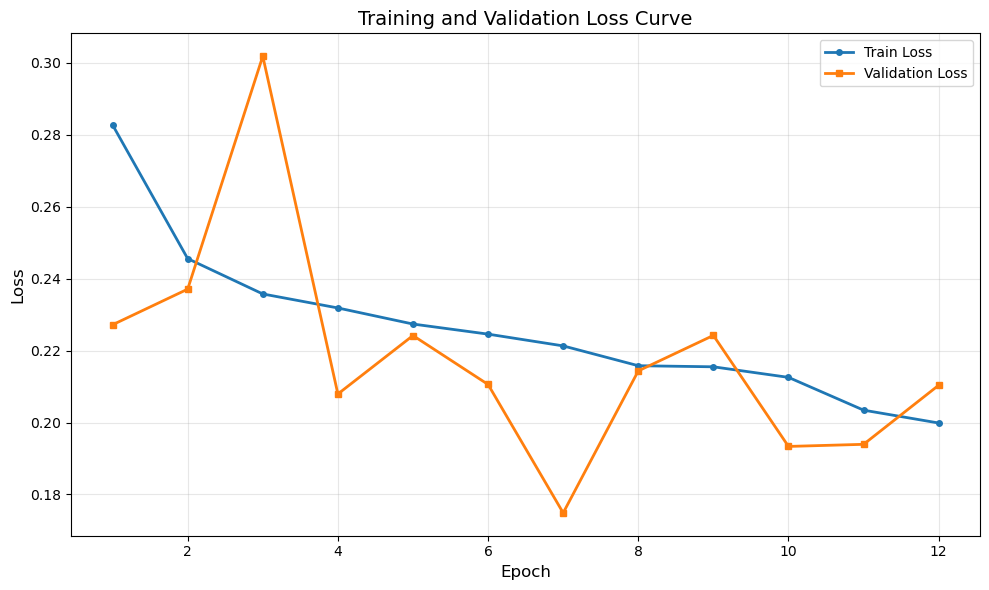

Learning curve displayed!


In [10]:
# ───────────────────────────────
# 学習曲線の描画（修正版）
# ───────────────────────────────
plt.figure(figsize=(10, 6))

# 実際に記録されたデータ数に合わせて横軸を作る
epochs_actual = len(train_losses)  # または len(val_losses) でもOK（本来は同じはず）

plt.plot(range(1, epochs_actual + 1), train_losses, 
         label='Train Loss', marker='o', linewidth=2, markersize=4)
plt.plot(range(1, epochs_actual + 1), val_losses, 
         label='Validation Loss', marker='s', linewidth=2, markersize=4)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss Curve', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 保存
os.makedirs("results", exist_ok=True)
curve_path = "results/learning_curve.png"
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
print(f"Learning curve saved to {curve_path}")

# 表示
plt.show()
print("Learning curve displayed!")

In [11]:
# ───────────────────────────────
# 学習曲線データをJSONファイルに保存
# ───────────────────────────────
os.makedirs("results", exist_ok=True)
metrics_data = {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accs': train_accs,
    'val_accs': val_accs,
    'epochs': epochs,
    'batch_size': batch_size,
    'learning_rate': lr,
    'num_points': num_points
}

json_path = "results/training_metrics.json"
with open(json_path, 'w') as f:
    json.dump(metrics_data, f, indent=4)
print(f"Training metrics saved to {json_path}")

Training metrics saved to results/training_metrics.json


In [12]:
def run_inference(
    data_root: str = "./WADS/wads",
    splits_file: str = "splits.json",
    checkpoint: str = "checkpoints/pointnet2_best.pth",
    num_points: int = 16384,
    batch_size: int = 2,
    num_workers: int = 4,
    save_results: bool = False,
    output_path: str = "results/test_results.txt",
):
    """
    推論のメイン処理（argparse を使わない版）
    """
    print(f"使用デバイス: {device}")

    # モデルの読み込み
    print(f"\nモデルを読み込み中: {checkpoint}")
    model = PointNet2(in_dim=5, num_classes=2, num_points=num_points).to(device)
    model.load_state_dict(torch.load(checkpoint, map_location=device))
    model.eval()
    print("モデルの読み込み完了")

    # テストデータセットの準備
    print(f"\nテストデータセットを準備中: {data_root}")
    test_dataset = WADSDataset(
        root_dir=data_root,
        split="test",
        num_points=num_points,
        splits_file=splits_file,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    print(f"テストデータ数: {len(test_dataset)} samples")

    # 評価実行
    conf_matrix, recall = evaluate_test_set(model, test_loader, device)

    # 結果表示
    print_evaluation_results(conf_matrix, recall)

    # 結果をファイルに保存（オプション）
    if save_results:
        os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)
        with open(output_path, "w") as f:
            f.write("混同行列:\n")
            f.write(f"{conf_matrix}\n\n")
            f.write(f"再現率 (Recall): {recall:.4f}\n")
        print(f"結果を保存しました: {output_path}")

In [13]:
run_inference()

使用デバイス: cuda

モデルを読み込み中: checkpoints/pointnet2_best.pth
モデルの読み込み完了

テストデータセットを準備中: ./WADS/wads
Loading test split with sequences: [34, 35, 36, 37, 76]
  Sequence 34: 101 files
  Sequence 35: 101 files
  Sequence 36: 102 files
  Sequence 37: 101 files
  Sequence 76: 5 files
Total test samples: 410
テストデータ数: 410 samples

=== テストデータでの評価を開始 ===


推論中: 100%|██████████| 205/205 [09:27<00:00,  2.77s/batch]



評価結果

【混同行列】
                予測
              0 (正常)  1 (ノイズ)
実際 0 (正常)    5712307    640642
     1 (ノイズ)    14907    349584

【評価指標】
Accuracy (精度):     0.9024 (90.24%)
Recall (再現率):     0.9591 (95.91%)
Precision (適合率):  0.3530 (35.30%)
F1 Score:           0.5161

【詳細統計】
True Positives (TP):    349584  (ノイズを正しくノイズと予測)
True Negatives (TN):   5712307  (正常を正しく正常と予測)
False Positives (FP):   640642  (正常を誤ってノイズと予測)
False Negatives (FN):    14907  (ノイズを誤って正常と予測)

